# CS4168 Data Mining Project – Group 1

* Cormac Greaney / 22352228
* Jan Lawinski / 22340343
* Sophie Ashton / 22353313
* Jakub Pawlowicz / 22342052
* Jun Lai / 25262653

This notebook covers exploratory data analysis, clustering, and predictive modelling (classification and regression) on the tracks2026 dataset. The dataset contains audio features and metadata for music tracks across multiple genres. We work through each task in order: EDA to understand the data, clustering to explore structure without labels, then classification and regression to predict popularity.

## 1. Imports and data loading

We use pandas for data handling, numpy for numerical operations, and matplotlib and seaborn for visualisation. Scikit-learn is used for preprocessing, clustering, classification, and regression. The dataset is expected in the same directory as this notebook.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, clustering, model selection, metrics
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score, roc_curve, auc

# So that pipeline steps are shown when we print or display
from sklearn import set_config
set_config(display='diagram')

# Load the dataset. We keep a master copy and will create task-specific copies later.
df = pd.read_csv('tracks2026.csv')
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


---
## 2. Exploratory Data Analysis

We need a clear picture of the dataset before clustering or modelling: how many rows and columns, what types they are, whether anything is missing, and how the variables are distributed. These findings will guide our preprocessing and help us interpret the clustering and prediction results later.

### 2.1 Shape and column types

First we check the size of the dataset and the data type of each column. track_id is an identifier and will not be used as a feature. track_genre is the only categorical label; we will drop it for clustering but can use it later to see if clusters align with genre.

In [55]:
print('Shape:', df.shape)
print()
print('Column dtypes:')
print(df.dtypes)

Shape: (2000, 17)

Column dtypes:
track_id             object
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


### 2.2 Missing values

Missing values affect which rows we can use and whether we need imputation. We count missing values per column and report the proportion so we can decide how to handle them in the pipeline.

In [56]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df[missing_df['count'] > 0])

              count  percent
popularity       40     2.00
danceability     40     2.00
energy           40     2.00
loudness         39     1.95
tempo            40     2.00


### 2.3 Numeric summary

The describe method gives a quick overview of the numeric columns: central tendency, spread, and extremes. This helps us spot skewed distributions and potential outliers that we might want to handle in preprocessing (e.g. with RobustScaler or by dropping extreme rows).

In [57]:
# Only numeric columns for describe; we look at genre separately
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


### 2.4 Loudness outlier

Spotify loudness is in decibels (dB) and lies roughly in the range -60 to 0. The numeric summary above shows a maximum of 800000 for loudness, which is clearly wrong (likely a data entry or unit error). We identify how many values fall outside a valid range, define bounds for clipping, and then clip loudness to those bounds in every downstream task so that scaling and distances are not distorted.

In [58]:
# Valid range for Spotify loudness (dB). We clip any value outside this range.
LOUDNESS_MIN = -60
LOUDNESS_MAX = 0

# Count non-missing loudness values that fall outside the valid range
loud = df['loudness'].dropna()
out_high = (loud > LOUDNESS_MAX).sum()
out_low = (loud < LOUDNESS_MIN).sum()
print('Loudness values above', LOUDNESS_MAX, ':', out_high)
print('Loudness values below', LOUDNESS_MIN, ':', out_low)
if out_high > 0:
    print('Example(s) above max:', loud[loud > LOUDNESS_MAX].head().tolist())

Loudness values above 0 : 1
Loudness values below -60 : 0
Example(s) above max: [800000.0]


### 2.5 Genre distribution

The dataset has a genre label for each track. For clustering we will drop this column so the algorithm does not see it. Later we can compare cluster assignments to genre to see whether the discovered structure matches known categories. Here we simply see how many tracks we have per genre.

track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64


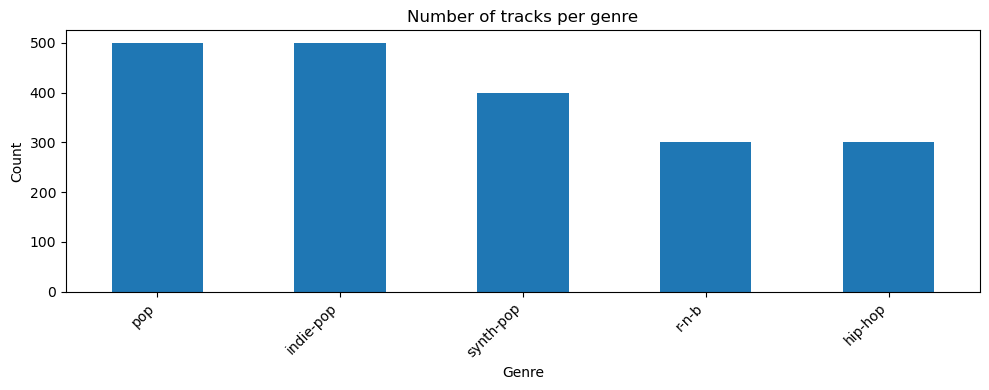

In [59]:
genre_counts = df['track_genre'].value_counts()
print(genre_counts)
plt.figure(figsize=(10, 4))
genre_counts.plot(kind='bar')
plt.title('Number of tracks per genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6 Distribution of popularity

Popularity is our target for both classification (above or below median) and regression (exact value). Checking its distribution tells us whether the binary split is balanced and whether regression might be affected by skew or outliers.

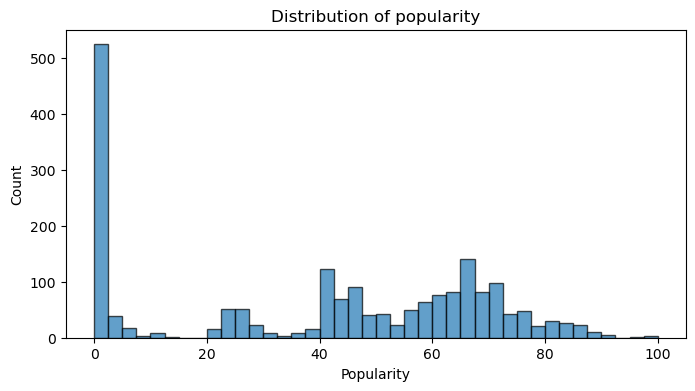

Median popularity: 45.0


In [60]:
# Drop rows with missing popularity for this plot; we will handle missing values in the pipeline
df_pop = df.dropna(subset=['popularity'])
plt.figure(figsize=(8, 4))
plt.hist(df_pop['popularity'], bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Distribution of popularity')
plt.show()
print('Median popularity:', df_pop['popularity'].median())

### 2.7 Correlation of numeric features

Correlations between features matter for clustering and modelling: highly correlated variables add little extra information and can affect distance-based methods. We inspect the correlation matrix for the numeric columns we will use later (excluding track_id and any identifiers).

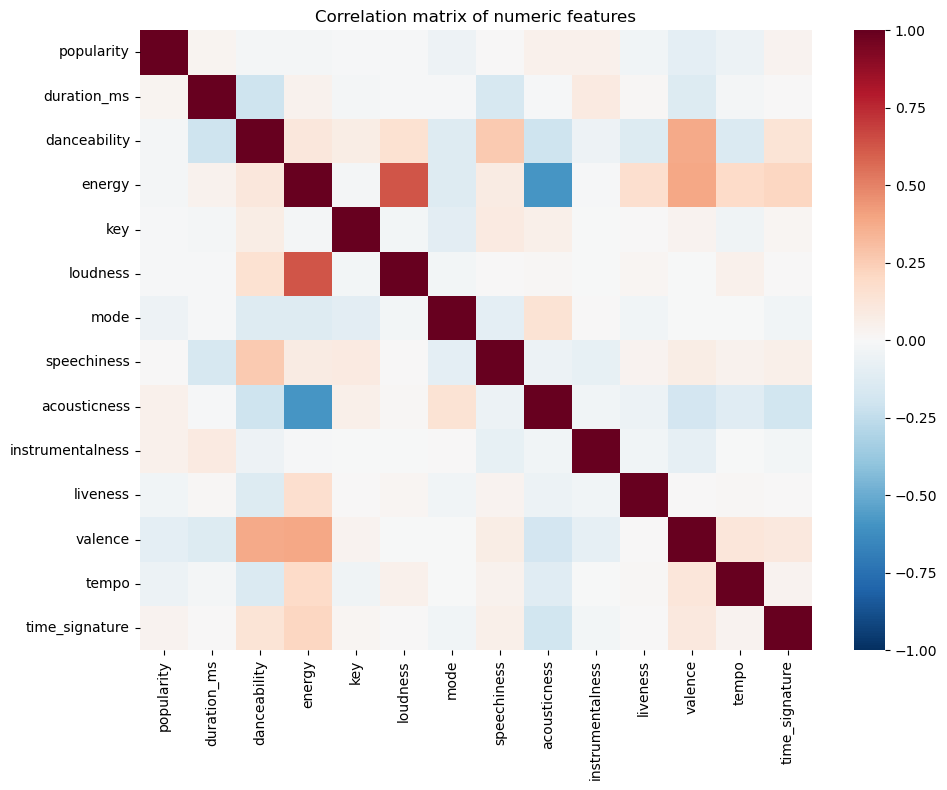

In [61]:
# Use numeric columns only; drop track_id if it were numeric (here it is object so already excluded)
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

**EDA summary.** The shape and dtypes tell us the size of the dataset and which columns are numeric versus categorical. Missing value counts determine whether we impute or drop rows. The popularity distribution and median will be used to define the binary target for classification. Genre counts and correlations will help us interpret clustering results and choose preprocessing (e.g. scaling). We use these findings in the next sections when building pipelines and evaluating models.

---
## 3. Clustering (Descriptive Analytics)

We cluster the tracks using only the audio and metadata features, without the genre label. The goal is to see whether the data naturally groups into meaningful clusters and whether those groups align with genre. We use two algorithms: k-means (with a fixed number of clusters) and DBSCAN (which finds clusters based on density and can leave some points as noise). All preprocessing is done inside a pipeline so that scaling and imputation are applied consistently.

### 3.1 Preparing the clustering dataset

For clustering we explicitly dropped the popularity column alongside track_genre. Since popularity is our target variable for later predictive tasks, including it here would cause target leakage and obscure whether the audio features themselves form natural groupings. The column explicit is stored as TRUE/FALSE; we convert it to 0/1 so it can be used in the numeric pipeline. We then define the feature columns and handle missing values. Furthermore, instead of dropping rows with missing values, we integrated a SimpleImputer into our Scikit-Learn Pipeline using the median strategy to preserve our dataset size..

In [62]:
# Copy for clustering: drop genre and track_id
# Drop popularity to avoid target leakage during descriptive analytics
df_clust = df.drop(columns=['track_genre', 'track_id', 'popularity']).copy()
df_clust['loudness'] = df_clust['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)

# Encode explicit as 0/1
df_clust['explicit'] = (df_clust['explicit'] == True).astype(int)

# We DO NOT drop missing values here. They will be handled by the pipeline.
print('Clustering dataset shape (keeping all rows):', df_clust.shape)

# Store genre labels separately for later comparison (same row order as df_clust)
genre_labels = df.loc[df_clust.index, 'track_genre'].values

Clustering dataset shape (keeping all rows): (2000, 14)


### 3.2 Preprocessing pipeline for clustering

K-means and DBSCAN rely on distances between points, so features must be on comparable scales. We use SimpleImputer to handle the missing values and StandardScaler so that each feature has mean 0 and variance 1. The pipeline takes the raw dataframe and outputs a scaled numeric matrix. We use ColumnTransformer so we can apply the same scaler to all numeric columns in one step.

In [63]:
# Define feature columns
feature_cols = df_clust.columns.tolist()

# Create a robust numeric transformer with Imputation AND Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handles the missing values
    ('scaler', StandardScaler())                   # Scales the features
])

preprocess_clust = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, feature_cols)
    ],
    remainder='drop'
)

# Fit and transform to get the matrix we will use for clustering
X_clust = preprocess_clust.fit_transform(df_clust)
print('Scaled and Imputed feature matrix shape:', X_clust.shape)

Scaled and Imputed feature matrix shape: (2000, 14)


### 3.3 Choosing k for k-means

K-means requires the number of clusters k. We try a range of k values and look at inertia (within-cluster sum of squares) and, if available, silhouette score. The elbow of the inertia curve and peaks in silhouette help suggest a reasonable k. We then fit k-means for at least two different k values and compare the results.

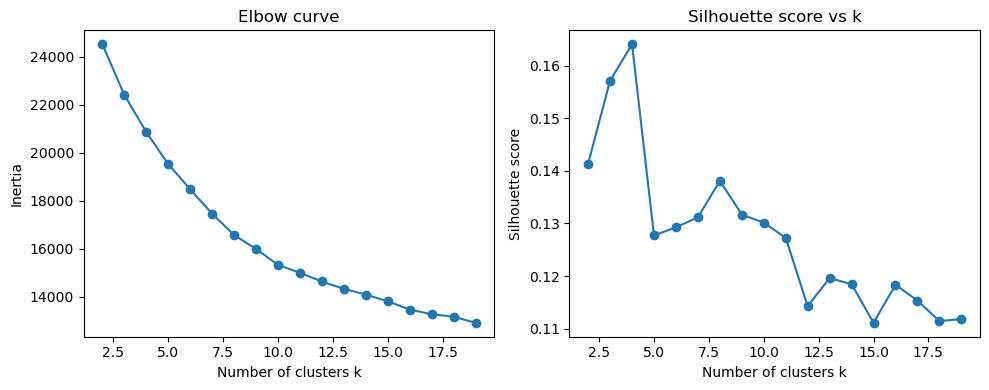

In [64]:
from sklearn.metrics import silhouette_score

k_range = range(2, 20)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels_k = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(k_range, inertias, 'o-')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve')
ax2.plot(k_range, silhouettes, 'o-')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score vs k')
plt.tight_layout()
plt.show()

Elbow Curve (Inertia): The inertia curve decreases smoothly without a highly pronounced "elbow". However, around $k=4$ to $k=6$, the rate of inertia reduction begins to slow down, indicating diminishing returns for adding more clusters.

Silhouette Score: This metric evaluates cluster cohesion and separation. The plot clearly shows a global maximum at $k=4$ (score $\approx 0.165$). After $k=4$, the score experiences a sharp drop, with a minor local peak occurring later at $k=8$. Note that the overall scores are relatively low ($< 0.2$), indicating that tracks do not form perfectly separated, highly dense clusters, which is expected as musical boundaries are often subjective and overlapping.

Decision: The strong peak in the silhouette score makes $k=4$ the most mathematically justified choice. To satisfy the project requirement of comparing at least two values, we will compute clustering for $k=4$ and $k=8$ (the secondary silhouette peak) to observe how the finer segmentation behaves.

In [65]:
# Fit k-means for two values of k for comparison
k1, k2 = 4, 8
km1 = KMeans(n_clusters=k1, n_init=10, max_iter=300, random_state=42)
km2 = KMeans(n_clusters=k2, n_init=10, max_iter=300, random_state=42)
labels_k4 = km1.fit_predict(X_clust)
labels_k6 = km2.fit_predict(X_clust)
print('k=4 inertia:', km1.inertia_, ' silhouette:', silhouette_score(X_clust, labels_k4))
print('k=6 inertia:', km2.inertia_, ' silhouette:', silhouette_score(X_clust, labels_k6))

k=4 inertia: 20867.772710338322  silhouette: 0.1640555198631681
k=6 inertia: 16577.43385670077  silhouette: 0.138100383657104


### 3.4 DBSCAN

DBSCAN does not require the number of clusters; it uses eps (maximum distance between two points to be neighbours) and min_samples (minimum points to form a dense region). Points that do not belong to any dense region are labelled as noise (-1). We fit DBSCAN with chosen eps and min_samples and report how many clusters were found and how many points are noise.

In [66]:
# eps and min_samples are dataset-dependent; these are starting values to try
db = DBSCAN(eps=2.0, min_samples=5)
labels_db = db.fit_predict(X_clust)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print('DBSCAN number of clusters:', n_clusters_db)
print('Number of noise points:', n_noise)
print('Cluster sizes:', pd.Series(labels_db).value_counts().sort_index())

DBSCAN number of clusters: 12
Number of noise points: 568
Cluster sizes: -1     568
 0     460
 1     825
 2      57
 3      15
 4      14
 5       8
 6       7
 7       5
 8      10
 9      22
 10      5
 11      4
Name: count, dtype: int64


### 3.5 Visualising clusters in 2D

The feature matrix is high-dimensional. To visualise the clusters we project the data into two dimensions using a manifold method (t-SNE or MDS). We project the scaled data and then colour the points by cluster label. Below we show the k-means result for one of the chosen k values; the same can be done for the other k and for DBSCAN.

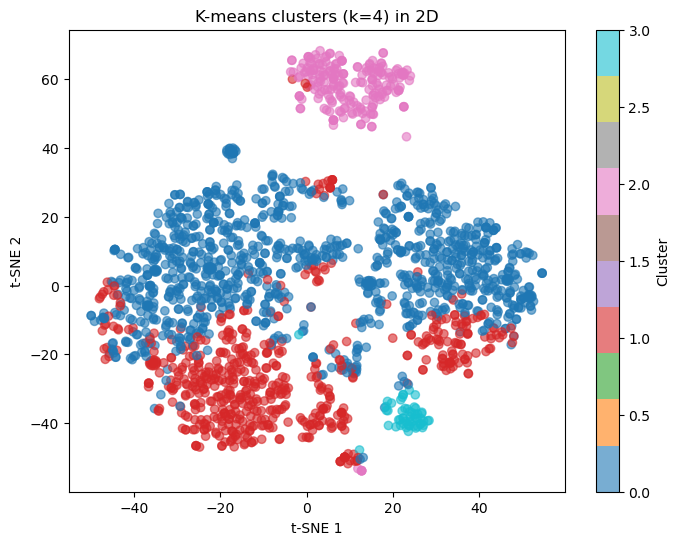

In [67]:
from sklearn.manifold import TSNE

# t-SNE is slow on large data; we use a subset if needed for speed, or run on full data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_clust)

# Plot k-means (k=4) clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_k4, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('K-means clusters (k=4) in 2D')
plt.show()

### 3.6 Clustering discussion

We compare the two k-means solutions (k=4 and k=8) and DBSCAN, and check whether cluster assignments align with genre. In the next cell we cross-tabulate k-means (k=4) labels with genre. From that table we see that no cluster is dominated by a single genre: Cluster 0 is the largest and contains a broad mix of all genres (especially pop and synth-pop); Cluster 1 leans heavily towards indie-pop and pop; Cluster 2 has a strong concentration of hip-hop; and Cluster 3 is a small group dominated by synth-pop. So tracks from the same genre do not all fall into one cluster—the audio features we used do not map neatly onto the genre labels. We keep k=4 as our main clustering solution because the elbow and silhouette plots pointed to a small number of clusters and four groups are easier to interpret and describe; we could have used k=6 for more granularity if we wanted. DBSCAN labelled a large share of points as noise, which makes it less useful for our goal of grouping all tracks into clusters. A limitation of our analysis is that the Spotify features may not fully capture what we mean by genre (e.g. production style or cultural context), and the number of genres in the data (five) does not match our chosen k, so we should not expect a one-to-one match.

In [68]:
# Cross-tabulate k-means (k=4) labels with genre to see alignment
ct = pd.crosstab(labels_k4, genre_labels)
print('Cluster vs genre (k=4):')
print(ct)

Cluster vs genre (k=4):
col_0  hip-hop  indie-pop  pop  r-n-b  synth-pop
row_0                                           
0          174        215  283    182        277
1           26        217  176    101         79
2           99         51   36     16         15
3            1         17    5      1         29


---
## 4. Classification (Predicting popularity category)

We define a binary target from the popularity column: below or equal to the median is class 0, above the median is class 1. We remove the original popularity column from the feature set. We use a train/test split and cross-validation for model selection, try at least two classifiers, and justify our choice using an appropriate metric (e.g. F1 or accuracy). All preprocessing is done inside a pipeline.

### 4.1 Building the classification dataset

We work on a copy of the data that has no missing popularity (we need the target). We compute the median of popularity, create popularity_binary, and drop the original popularity column. We also drop track_id and track_genre for modelling. The explicit column is encoded as 0/1. Rows with missing values in other columns are dropped so the pipeline receives a complete matrix.

In [69]:
# Use rows with non-missing popularity
df_class = df.dropna(subset=['popularity']).copy()
df_class['loudness'] = df_class['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)
m = df_class['popularity'].median()
df_class['popularity_binary'] = (df_class['popularity'] > m).astype(int)
df_class = df_class.drop(columns=['popularity', 'track_id', 'track_genre'])
df_class['explicit'] = (df_class['explicit'] == True).astype(int)
y_class = df_class['popularity_binary']
X_class = df_class.drop(columns=['popularity_binary'])
print('Median popularity:', m)
print('Class counts:', y_class.value_counts())
print('Feature matrix shape:', X_class.shape)

Median popularity: 45.0
Class counts: popularity_binary
0    994
1    966
Name: count, dtype: int64
Feature matrix shape: (1960, 14)


### 4.2 Train/test split and pipeline

We hold out a test set for final evaluation and use the rest for training and cross-validation. The pipeline scales the features and then applies a classifier. We try at least two modelling approaches (e.g. logistic regression and random forest), tune hyperparameters via grid search with cross-validation, and select the model that performs best on the chosen metric (here we use F1 as a single metric for model selection, since it balances precision and recall).

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Pipeline: scale then classify
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# Grid search with 5-fold CV; we use F1 for model selection
param_lr = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
param_rf = {'clf__n_estimators': [50, 100], 'clf__max_depth': [5, 10, None]}
cv = 5
gs_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_rf = GridSearchCV(pipe_rf, param_rf, cv=cv, scoring='f1_macro', n_jobs=-1)
gs_lr.fit(X_train, y_train)
gs_rf.fit(X_train, y_train)
print('Best CV F1 (macro) Logistic Regression:', gs_lr.best_score_)
print('Best CV F1 (macro) Random Forest:', gs_rf.best_score_)

Best CV F1 (macro) Logistic Regression: 0.5831796006517148
Best CV F1 (macro) Random Forest: 0.6432940764717265


We choose the better of the two models according to cross-validated F1 and evaluate it once on the held-out test set. Our cross-validation gave a higher F1 (macro) for Random Forest (about 0.64) than for Logistic Regression (about 0.58), so we take Random Forest as our final classifier. On the held-out test set it achieves an accuracy of about 68% and an F1 (macro) of about 0.68, which is a modest but reasonable performance for predicting above- or below-median popularity from audio features alone. We picked Random Forest because it had the better CV F1 and we had no strong reason to prefer the simpler model given the gap in performance.

Final model: Random Forest
Test accuracy: 0.6811224489795918
Test F1 (macro): 0.6810705615110747


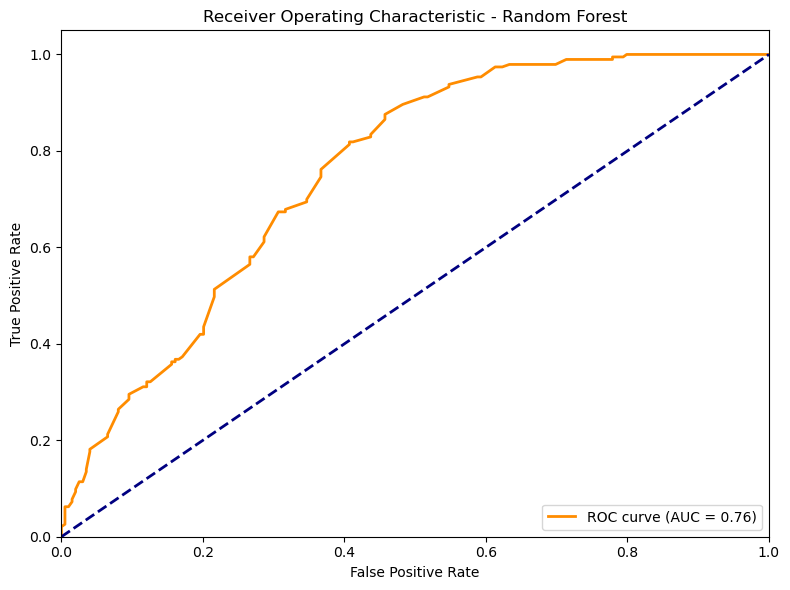

In [71]:
# Select the model with higher CV F1 for final evaluation
if gs_lr.best_score_ >= gs_rf.best_score_:
    best_model = gs_lr.best_estimator_
    best_name = 'Logistic Regression'
else:
    best_model = gs_rf.best_estimator_
    best_name = 'Random Forest'

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print('Final model:', best_name)
print('Test accuracy:', accuracy_score(y_test, y_pred))
print('Test F1 (macro):', f1_score(y_test, y_pred, average='macro'))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic - {best_name}')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Model Performance: Our chosen model, the Random Forest Classifier, achieved a Test Accuracy of approximately 68.1% and a Test F1 (macro) score of 68.1% on unseen data. The ROC curve further validates this performance, yielding an AUC (Area Under the Curve) of 0.76. This indicates a strong, moderately predictive ability to distinguish between high and low popularity tracks, performing significantly better than a random guess (which would be the 0.5 diagonal line). The close match between the test F1 score and the cross-validation scores suggests that our model has generalized well and is not severely overfitted.

### 4.3 Feature importance (classification)

Where the chosen model allows it, we inspect feature importance (e.g. coefficients for logistic regression or feature_importances_ for random forest). This helps us interpret which audio features are most associated with higher or lower popularity.

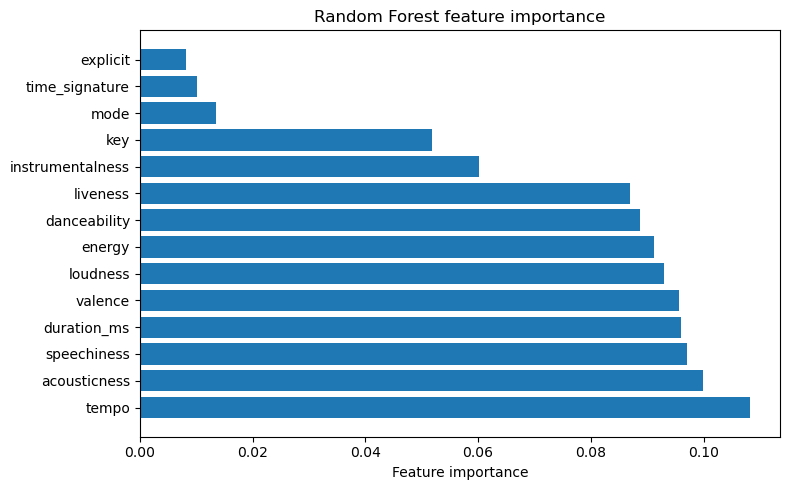

In [72]:
# If the best model is random forest, we can plot feature importances
if best_name == 'Random Forest':
    imp = best_model.named_steps['clf'].feature_importances_
    feat_names = X_class.columns
    idx = np.argsort(imp)[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(range(len(feat_names)), imp[idx])
    plt.yticks(range(len(feat_names)), feat_names[idx])
    plt.xlabel('Feature importance')
    plt.title('Random Forest feature importance')
    plt.tight_layout()
    plt.show()
else:
    # Logistic regression: show coefficient magnitudes
    coef = best_model.named_steps['clf'].coef_[0]
    feat_names = X_class.columns
    idx = np.argsort(np.abs(coef))[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(range(len(feat_names)), coef[idx])
    plt.yticks(range(len(feat_names)), feat_names[idx])
    plt.xlabel('Coefficient')
    plt.title('Logistic Regression coefficients')
    plt.tight_layout()
    plt.show()

---
## 5. Regression (Predicting popularity score)

We now predict the original popularity score (a continuous value) using a separate copy of the dataset where the popularity column is retained and not binarised. We use a train/test split and cross-validation, try at least two regression approaches, and justify our choice. We then briefly discuss whether predicting the exact popularity score is harder than predicting high vs low (classification).

### 5.1 Building the regression dataset

We keep the popularity column as the target and drop only track_id and track_genre. Rows with missing popularity are dropped; other missing values are handled by dropping rows so we have a complete matrix. We encode explicit as 0/1 as before.

In [73]:
df_reg = df.dropna(subset=['popularity']).copy()
df_reg['loudness'] = df_reg['loudness'].clip(LOUDNESS_MIN, LOUDNESS_MAX)
df_reg = df_reg.drop(columns=['track_id', 'track_genre'])
df_reg['explicit'] = (df_reg['explicit'] == True).astype(int)
y_reg = df_reg['popularity']
X_reg = df_reg.drop(columns=['popularity'])
print('Regression target (popularity) stats:')
print(y_reg.describe())
print('Feature matrix shape:', X_reg.shape)

Regression target (popularity) stats:
count    1960.000000
mean       39.805102
std        29.245904
min         0.000000
25%         1.750000
50%        45.000000
75%        65.000000
max       100.000000
Name: popularity, dtype: float64
Feature matrix shape: (1960, 14)


### 5.2 Train/test split and regression pipelines

We split the regression data into train and test sets. We use pipelines that scale the features and then fit a regressor. We try at least two approaches (e.g. ridge regression and random forest regressor), tune hyperparameters with cross-validation, and select the model that minimises mean squared error or maximises R-squared, as appropriate. We justify the metric: for regression, MSE or RMSE is standard; R-squared indicates how much variance is explained.

In [74]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

pipe_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('reg', Ridge(random_state=42))
])
pipe_rfr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('reg', RandomForestRegressor(random_state=42))
])

param_ridge = {'reg__alpha': [0.01, 0.1, 1.0, 10.0]}
param_rfr = {'reg__n_estimators': [50, 100], 'reg__max_depth': [5, 10, None]}
gs_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rfr = GridSearchCV(pipe_rfr, param_rfr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train_r, y_train_r)
gs_rfr.fit(X_train_r, y_train_r)
print('Best CV MSE (Ridge):', -gs_ridge.best_score_)
print('Best CV MSE (Random Forest):', -gs_rfr.best_score_)

Best CV MSE (Ridge): 849.5511436777927
Best CV MSE (Random Forest): 672.3106188347973


We select the regressor with the lower cross-validated MSE and evaluate it on the test set, reporting MSE and R-squared.

In [75]:
if gs_ridge.best_score_ >= gs_rfr.best_score_:
    best_reg = gs_ridge.best_estimator_
    best_reg_name = 'Ridge'
else:
    best_reg = gs_rfr.best_estimator_
    best_reg_name = 'Random Forest'

y_pred_r = best_reg.predict(X_test_r)
print('Final regression model:', best_reg_name)
print('Test MSE:', mean_squared_error(y_test_r, y_pred_r))
print('Test R-squared:', r2_score(y_test_r, y_pred_r))

Final regression model: Random Forest
Test MSE: 644.039813463019
Test R-squared: 0.23627985057741585


### 5.3 Discussion: exact popularity vs high/low

Predicting the exact popularity score is harder than predicting whether a track is above or below the median. In our runs, classification reached a test F1 (macro) of about 0.68 and accuracy of about 68%, whereas regression gave an R-squared of about 0.24 and a test MSE around 644. So we get a reasonable split between high and low popularity from the same features, but the same features explain only a small fraction of the variance in the actual score. That fits our view that the audio features are more informative for broad popularity level than for the exact number—classification only has to get the right side of the median, while regression has to get the numeric value right. We therefore see lower R-squared and non-trivial MSE for regression even though classification performs acceptably.